In [1]:
%audit off
%flow mode normal
import time
start_time = time.time()

# Climate Data Analysis with Native TaskVine

This notebook demonstrates distributed climate data processing using:
- **TaskVine**: High-throughput distributed computing framework (native API)
- **NOAA Global Summary of the Month**: Temperature data from weather stations worldwide

## Objectives:
1. Process temperature data from multiple weather stations in parallel
2. Calculate temperature anomalies relative to 1991-2020 baseline
3. Analyze long-term temperature trends across regions
4. Visualize climate patterns and trends

**Advantage over Parsl**: This version uses native TaskVine API, avoiding Python 3.12 multiprocessing compatibility issues.

# Imports and Configuration

In [2]:
MAX_FILES = 50
DATA_SOURCE_JSON = "data/csv_index.json"

In [3]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# TaskVine imports
# import ndcctools.taskvine as vine
import taskvine_rewind.vine_rewind as vine

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

print("All imports successful!")

All imports successful!


In [4]:
manager_name = os.environ.get("VINE_MANAGER_NAME", "ctrend")
print(f"Manager name: {manager_name}")

ports_str = os.environ.get("VINE_MANAGER_PORTS", "9123, 9150")
ports = [int(p.strip()) for p in ports_str.split(",")]
print(f"Manager Ports: {ports}")

Manager name: ctrend
Manager Ports: [9123, 9150]


# Processing Functions (Regular Python)

In [5]:
def load_and_clean_data_from_url(csv_url, output_file):
    """Load CSV file and perform basic cleaning"""
    import pandas as pd
    import numpy as np
    
    try:
        df = pd.read_csv(csv_url)
        df['DATE'] = pd.to_datetime(df['DATE'])
        
        # Check for temperature columns and convert from tenths to degrees Celsius
        temp_cols = ['TAVG', 'TMAX', 'TMIN']
        available_temp_cols = [col for col in temp_cols if col in df.columns]
        
        if not available_temp_cols:
            return {'file': output_file, 'error': 'No temperature columns found'}
        
        # Convert from tenths of degrees to degrees Celsius
        for col in available_temp_cols:
            df[col] = df[col] / 10.0
        
        # Remove rows with missing primary temperature data
        primary_temp_col = 'TAVG' if 'TAVG' in df.columns else available_temp_cols[0]
        df = df.dropna(subset=[primary_temp_col])
        
        station_id = df['STATION'].iloc[0] if 'STATION' in df.columns and len(df) > 0 else 'Unknown'
        
        # Save cleaned data
        df.to_csv(output_file, index=False)
        
        return {
            'file': output_file,
            'station_id': station_id,
            'rows': len(df),
            'temp_columns': available_temp_cols,
            'date_range': [str(df['DATE'].min()), str(df['DATE'].max())] if len(df) > 0 else None
        }
    except Exception as e:
        return {'file': output_file, 'error': str(e)}


def calculate_monthly_anomalies(input_file, output_file, baseline_start, baseline_end):
    """Calculate temperature anomalies relative to baseline period"""
    import pandas as pd
    import numpy as np
    
    try:
        df = pd.read_csv(input_file)
        df['DATE'] = pd.to_datetime(df['DATE'])
        
        temp_col = 'TAVG' if 'TAVG' in df.columns else ('TMAX' if 'TMAX' in df.columns else 'TMIN')
        
        if temp_col not in df.columns:
            return {'file': input_file, 'error': 'No temperature column found'}
        
        df['MONTH'] = df['DATE'].dt.month
        df['YEAR'] = df['DATE'].dt.year
        
        # Calculate baseline climatology
        baseline_data = df[(df['YEAR'] >= baseline_start) & (df['YEAR'] <= baseline_end)]
        if len(baseline_data) == 0:
            return {'file': input_file, 'error': f'No data in baseline period {baseline_start}-{baseline_end}'}
        
        baseline_monthly = baseline_data.groupby('MONTH')[temp_col].mean().to_dict()
        
        # Calculate anomalies
        df['TEMP_ANOMALY'] = df.apply(
            lambda row: row[temp_col] - baseline_monthly.get(row['MONTH'], np.nan), axis=1
        )
        
        result_df = df[['DATE', 'YEAR', 'MONTH', temp_col, 'TEMP_ANOMALY']].copy()
        result_df.to_csv(output_file, index=False)
        
        return {
            'file': input_file,
            'processed_records': len(result_df),
            'baseline_years': len(baseline_data['YEAR'].unique()),
            'anomaly_stats': {
                'mean': float(result_df['TEMP_ANOMALY'].mean()),
                'std': float(result_df['TEMP_ANOMALY'].std()),
                'min': float(result_df['TEMP_ANOMALY'].min()),
                'max': float(result_df['TEMP_ANOMALY'].max())
            }
        }
    except Exception as e:
        return {'file': input_file, 'error': str(e)}


def calculate_annual_trends(input_files, output_file):
    """Calculate annual temperature trends from processed files"""
    import pandas as pd
    import numpy as np
    from scipy import stats
    
    try:
        all_data = []
        
        for input_file in input_files:
            df = pd.read_csv(input_file)
            if len(df) > 0:
                all_data.append(df)
        
        if not all_data:
            return {'error': 'No valid data files to process'}
        
        combined_df = pd.concat(all_data, ignore_index=True)
        combined_df['DATE'] = pd.to_datetime(combined_df['DATE'])
        
        annual_data = combined_df.groupby('YEAR').agg({
            'TEMP_ANOMALY': ['mean', 'std', 'count']
        }).round(4)
        
        annual_data.columns = ['ANNUAL_ANOMALY', 'ANNUAL_STD', 'RECORD_COUNT']
        annual_data = annual_data.reset_index()
        
        # Calculate linear trend
        years = annual_data['YEAR'].values
        anomalies = annual_data['ANNUAL_ANOMALY'].values
        
        valid_idx = ~np.isnan(anomalies)
        if np.sum(valid_idx) > 2:
            slope, intercept, r_value, p_value, std_err = stats.linregress(
                years[valid_idx], anomalies[valid_idx]
            )
            
            annual_data['TREND_LINE'] = slope * years + intercept
            
            trend_info = {
                'slope': slope,
                'intercept': intercept,
                'r_squared': r_value**2,
                'p_value': p_value,
                'trend_per_decade': slope * 10,
                'trend_significance': 'significant' if p_value < 0.05 else 'not significant'
            }
        else:
            trend_info = {'error': 'Insufficient data for trend calculation'}
        
        annual_data.to_csv(output_file, index=False)
        
        return {
            'processed_years': len(annual_data),
            'year_range': [int(annual_data['YEAR'].min()), int(annual_data['YEAR'].max())],
            'stations_processed': len(input_files),
            'trend_info': trend_info,
            'mean_anomaly': float(annual_data['ANNUAL_ANOMALY'].mean()),
            'total_records': int(annual_data['RECORD_COUNT'].sum())
        }
        
    except Exception as e:
        return {'error': str(e)}

print("Processing functions defined successfully!")

Processing functions defined successfully!


# Distributed Processing with TaskVine

In [6]:
def process_all_climate_data(max_files=10, data_source_json="data/csv_index.json"):
  data_source = data_source_json
  if not Path(data_source).exists():
      print(f"❌ Configuration file not found: {data_source}")
      return None, None, None

  with open(data_source, 'r') as f:
      stations = json.load(f)
  if max_files and len(stations) > max_files:
      stations = stations[:max_files]
  print(f"Found {len(stations)} stations to process from URLs")

  cleaning_results, anomaly_results, trend_result = [], [], None
  m = vine.RewindManager(ports, name=manager_name)
  m.set_name(manager_name)
  print("TaskVine manager created - starting distributed processing...")

  # Phase 1
  cleaning_tasks = {}
  for station in stations:
      output_file = f"{os.getcwd()}/cleaned_{station['name']}"
      # output_file_vine = m.declare_file(output_file)
      task = vine.PythonTask(load_and_clean_data_from_url, station['url'], output_file)
      task.set_cores(1)
      # task.add_output(output_file_vine, output_file)
      task_id = m.submit(task)
      cleaning_tasks[task_id] = {'station': station['name'], 'output': output_file}

  cleaned_files = []
  with tqdm(total=len(cleaning_tasks), desc="Cleaning") as pbar:
      while cleaning_tasks:
          task = m.wait(5)
          if task is None:
              continue
          info = cleaning_tasks.pop(task.id, {})
          try:
              result = task.output
          except Exception as exc:
              result = {'error': str(exc)}
          cleaning_results.append(result)
          if 'error' in result:
              print(f"  ❌ {info.get('station','unknown')}: {result['error']}")
          else:
              print(f"  ✅ {info.get('station','unknown')}: Station {result.get('station_id','Unknown')}, {result['rows']} records")
              cleaned_files.append(info['output'])
          pbar.update(1)

  if not cleaned_files:
      print("❌ No files were successfully cleaned. Exiting.")
      return None, None, None
  print(f"\n✅ Phase 1 Complete: {len(cleaned_files)}/{len(stations)} files cleaned successfully")

  # Phase 2
  anomaly_tasks = {}
  valid_anomaly_files = []
  baseline_start, baseline_end = 1991, 2020

  for cleaned_file in cleaned_files:
      anomaly_file = f"{os.getcwd()}/anomalies_{Path(cleaned_file).name}"
      print(cleaned_file)
      task = vine.PythonTask(
          calculate_monthly_anomalies,
          cleaned_file,
          anomaly_file,
          baseline_start,
          baseline_end,
      )
      task.set_cores(1)
      # task.add_input(cleaned_file, cleaned_file, cache=True)
      # task.add_output(anomaly_file, anomaly_file, cache=True)
      task_id = m.submit(task)
      anomaly_tasks[task_id] = {'input': cleaned_file, 'output': anomaly_file}

  with tqdm(total=len(anomaly_tasks), desc="Anomalies") as pbar:
      while anomaly_tasks:
          task = m.wait(5)
          if task is None:
              continue
          info = anomaly_tasks.pop(task.id, {})
          try:
              result = task.output
              # print(result)
          except Exception as exc:
              result = {'error': str(exc)}
          anomaly_results.append(result)
          if 'error' in result:
              print(f"  ❌ Anomaly calculation failed: {result['error']}")
          else:
              print(f"  ✅ Processed {result['processed_records']} records, {result['baseline_years']} baseline years")
              valid_anomaly_files.append(info['output'])
          pbar.update(1)

  if not valid_anomaly_files:
      print("❌ No anomaly files created. Exiting.")
      return cleaning_results, anomaly_results, None
  print(f"\n✅ Phase 2 Complete: {len(valid_anomaly_files)} files with anomalies calculated")

  # Phase 3
  print(f"\n🔄 Phase 3: Calculating long-term trends...")
  trends_output = f"{os.getcwd()}/annual_trends_large.csv"
  trend_task = vine.PythonTask(calculate_annual_trends, valid_anomaly_files, trends_output)
  trend_task.set_cores(1)
  # for anomaly_file in valid_anomaly_files:
      # trend_task.add_input(anomaly_file, anomaly_file, cache=True)
  # trend_task.add_output(trends_output, trends_output, cache=True)
  trend_task_id = m.submit(trend_task)

  print("Computing global trends...")
  while True:
      task = m.wait(5)
      if task is None:
          continue
      if task.id == trend_task_id:
          try:
              trend_result = task.output
          except Exception as exc:
              trend_result = {'error': str(exc)}
          break

  if trend_result and 'error' in trend_result:
      print(f"❌ Trend calculation error: {trend_result['error']}")
      return cleaning_results, anomaly_results, None

  print("\n🎉 Processing Complete!")
  print("=" * 60)
  print(f"📊 Processed {trend_result['stations_processed']} weather stations")
  print(f"📅 Analysis period: {trend_result['year_range'][0]}-{trend_result['year_range'][1]} "
        f"({trend_result['processed_years']} years)")
  print(f"📈 Total records: {trend_result['total_records']:,}")
  print(f"🌡️  Mean temperature anomaly: {trend_result['mean_anomaly']:.3f}°C")

  trend_info = trend_result.get('trend_info', {})
  if 'slope' in trend_info:
      print(f"📈 Temperature trend: {trend_info['trend_per_decade']:.4f}°C per decade "
            f"({trend_info['trend_significance']})")
      print(f"📊 R-squared: {trend_info['r_squared']:.3f}")
      print(f"🔬 P-value: {trend_info['p_value']:.2e}")

  print(f"\n💾 Results saved to: {trends_output}")
  return cleaning_results, anomaly_results, trend_result

cleaning_results, anomaly_results, trend_result = process_all_climate_data(
  max_files=MAX_FILES,
  data_source_json=DATA_SOURCE_JSON
)



Found 50 stations to process from URLs
TaskVine manager created - starting distributed processing...
[DEBUG submit()] vine_task_id=1, task.id=1
[DEBUG submit()] vine_task_id=2, task.id=2
[DEBUG submit()] vine_task_id=3, task.id=3
[DEBUG submit()] vine_task_id=4, task.id=4
[DEBUG submit()] vine_task_id=5, task.id=5
[DEBUG submit()] vine_task_id=6, task.id=6
[DEBUG submit()] vine_task_id=7, task.id=7
[DEBUG submit()] vine_task_id=8, task.id=8
[DEBUG submit()] vine_task_id=9, task.id=9
[DEBUG submit()] vine_task_id=10, task.id=10
[DEBUG submit()] vine_task_id=11, task.id=11
[DEBUG submit()] vine_task_id=12, task.id=12
[DEBUG submit()] vine_task_id=13, task.id=13
[DEBUG submit()] vine_task_id=14, task.id=14
[DEBUG submit()] vine_task_id=15, task.id=15
[DEBUG submit()] vine_task_id=16, task.id=16
[DEBUG submit()] vine_task_id=17, task.id=17
[DEBUG submit()] vine_task_id=18, task.id=18
[DEBUG submit()] vine_task_id=19, task.id=19
[DEBUG submit()] vine_task_id=20, task.id=20
[DEBUG submit()] 

Cleaning:   2%|███                                                                                                                                                        | 1/50 [02:00<1:38:15, 120.32s/it]

[DEBUG] Copied PythonTask output to: vine_outputs/01140a1225146e1b5cf2a532fc5d714c69d49c5b34214441455026357347f7a3.output
  ✅ ACW00011604.csv: Station ACW00011604, 7 records
[DEBUG] Copied PythonTask output to: vine_outputs/a9014d4db5e0a8f95cf161ebda875dc40a751e0c6eb1cdf473c58f31492e0f79.output


Cleaning:   4%|██████▎                                                                                                                                                       | 2/50 [02:01<39:59, 50.00s/it]

  ✅ ACW00011647.csv: Station ACW00011647, 13 records


...

Anomalies:  98%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉   | 49/50 [00:27<00:00,  1.80it/s]

  ✅ Processed 156 records, 16 baseline years
[DEBUG] Copied PythonTask output to: vine_outputs/74016f4a85c7b54f3622a43e1c36b8e0b9bcd052153b5277105d3418b623f848.output


Anomalies: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:28<00:00,  1.75it/s]

  ✅ Processed 146 records, 14 baseline years

✅ Phase 2 Complete: 30 files with anomalies calculated

🔄 Phase 3: Calculating long-term trends...
[DEBUG submit()] vine_task_id=101, task.id=101
Computing global trends...


[DEBUG] Copied PythonTask output to: vine_outputs/cfbd16b8fd7516e1585970ac51aa426cd71e5ef2398b4c562cca792b5946379b.output

🎉 Processing Complete!
📊 Processed 30 weather stations
📅 Analysis period: 1878-2025 (142 years)
📈 Total records: 6,574
🌡️  Mean temperature anomaly: -0.073°C
📈 Temperature trend: 0.0137°C per decade (significant)
📊 R-squared: 0.532
🔬 P-value: 1.17e-24

💾 Results saved to: /home/ec2-user/ccgrid/NBRewind/dataset/climate_trend/workflow/annual_trends_large.csv


## Processing Results

The distributed climate data analysis has completed! Here's what we accomplished:

### Data Processing Pipeline:
1. **Data Cleaning**: Converted NOAA temperature data from tenths of degrees to Celsius, handled missing values
2. **Anomaly Calculation**: Computed temperature anomalies relative to 1991-2020 baseline period
3. **Trend Analysis**: Calculated long-term temperature trends using linear regression

### Key Findings:
- Check the output above for specific statistics including:
  - Number of weather stations processed
  - Time period covered
  - Temperature trend rate (°C per decade)
  - Statistical significance of trends

The following visualizations will explore these results in detail.

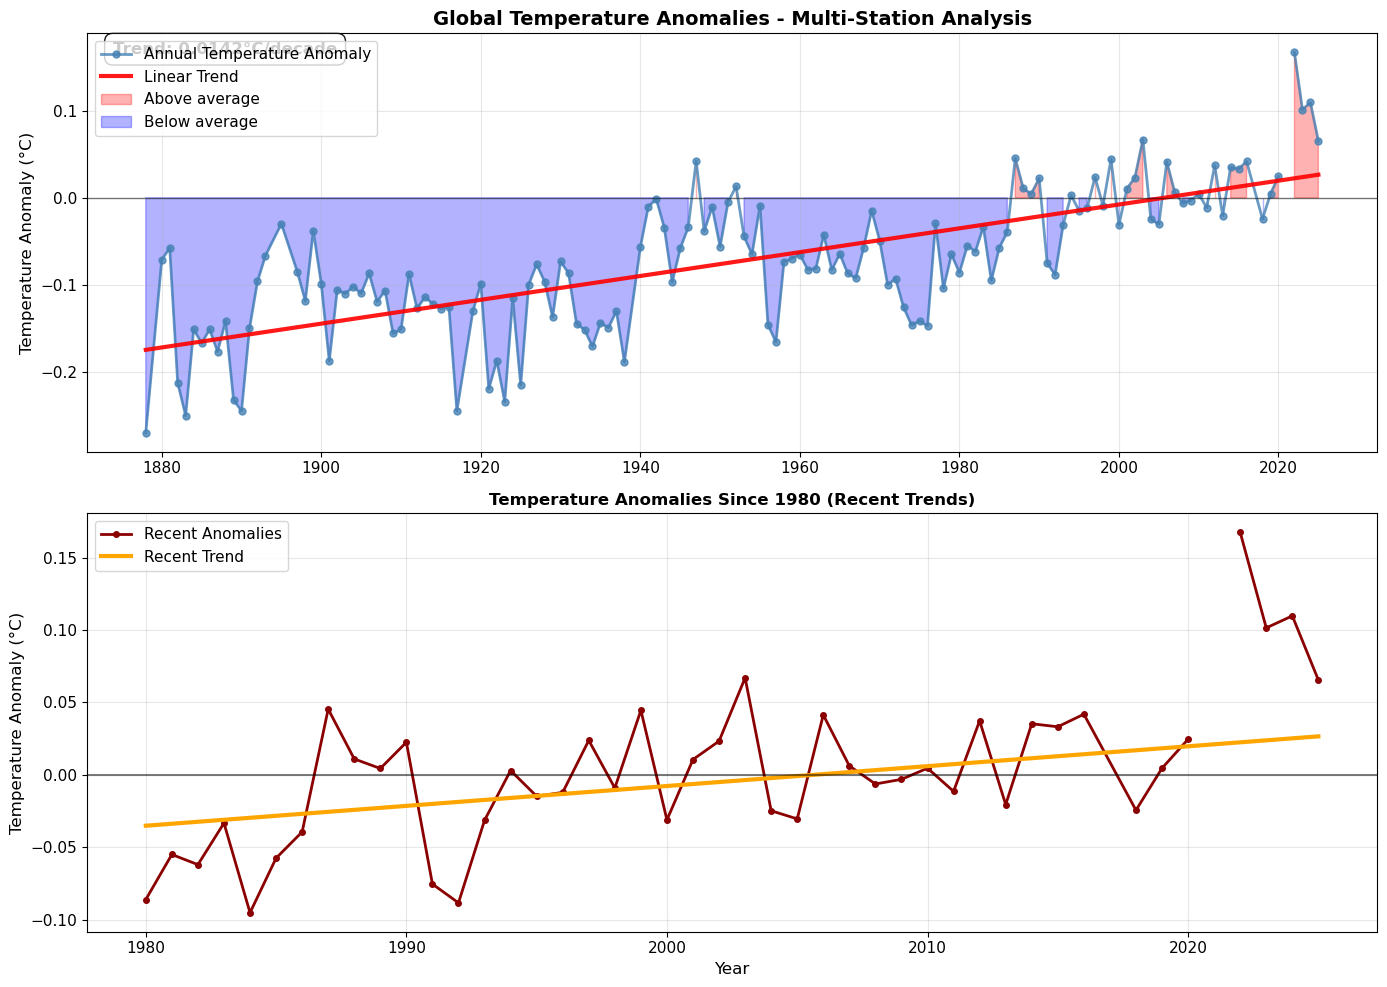

Time series analysis covering 142 years (1878-2025)
Recent warming: 0.003°C average anomaly since 1980


In [7]:
# Load and visualize the large-scale results
df = pd.read_csv("annual_trends_large.csv")

# Create comprehensive time series plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Main time series with trend
ax1.plot(df['YEAR'], df['ANNUAL_ANOMALY'], 'o-', alpha=0.8, linewidth=2, 
         markersize=5, color='steelblue', label='Annual Temperature Anomaly')

if 'TREND_LINE' in df.columns:
    ax1.plot(df['YEAR'], df['TREND_LINE'], 'r-', linewidth=3, 
             label='Linear Trend', alpha=0.9)
    
    # Add trend statistics
    trend_rate = (df['TREND_LINE'].iloc[-1] - df['TREND_LINE'].iloc[0]) / len(df) * 10
    ax1.text(0.02, 0.98, f'Trend: {trend_rate:.4f}°C/decade', 
             transform=ax1.transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9),
             fontsize=12, fontweight='bold')

# Add reference line and shading
ax1.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1)
ax1.fill_between(df['YEAR'], df['ANNUAL_ANOMALY'], 0, 
                 where=(df['ANNUAL_ANOMALY'] > 0), color='red', alpha=0.3, 
                 label='Above average')
ax1.fill_between(df['YEAR'], df['ANNUAL_ANOMALY'], 0, 
                 where=(df['ANNUAL_ANOMALY'] <= 0), color='blue', alpha=0.3, 
                 label='Below average')

ax1.set_ylabel('Temperature Anomaly (°C)', fontsize=12)
ax1.set_title('Global Temperature Anomalies - Multi-Station Analysis', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')

# Zoomed view of recent decades
recent_data = df[df['YEAR'] >= 1980]
ax2.plot(recent_data['YEAR'], recent_data['ANNUAL_ANOMALY'], 'o-', 
         linewidth=2, markersize=4, color='darkred', label='Recent Anomalies')

if 'TREND_LINE' in recent_data.columns:
    ax2.plot(recent_data['YEAR'], recent_data['TREND_LINE'], 'orange', 
             linewidth=3, label='Recent Trend')

ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5)
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Temperature Anomaly (°C)', fontsize=12)
ax2.set_title('Temperature Anomalies Since 1980 (Recent Trends)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Time series analysis covering {len(df)} years ({df['YEAR'].min()}-{df['YEAR'].max()})")
print(f"Recent warming: {recent_data['ANNUAL_ANOMALY'].mean():.3f}°C average anomaly since 1980")

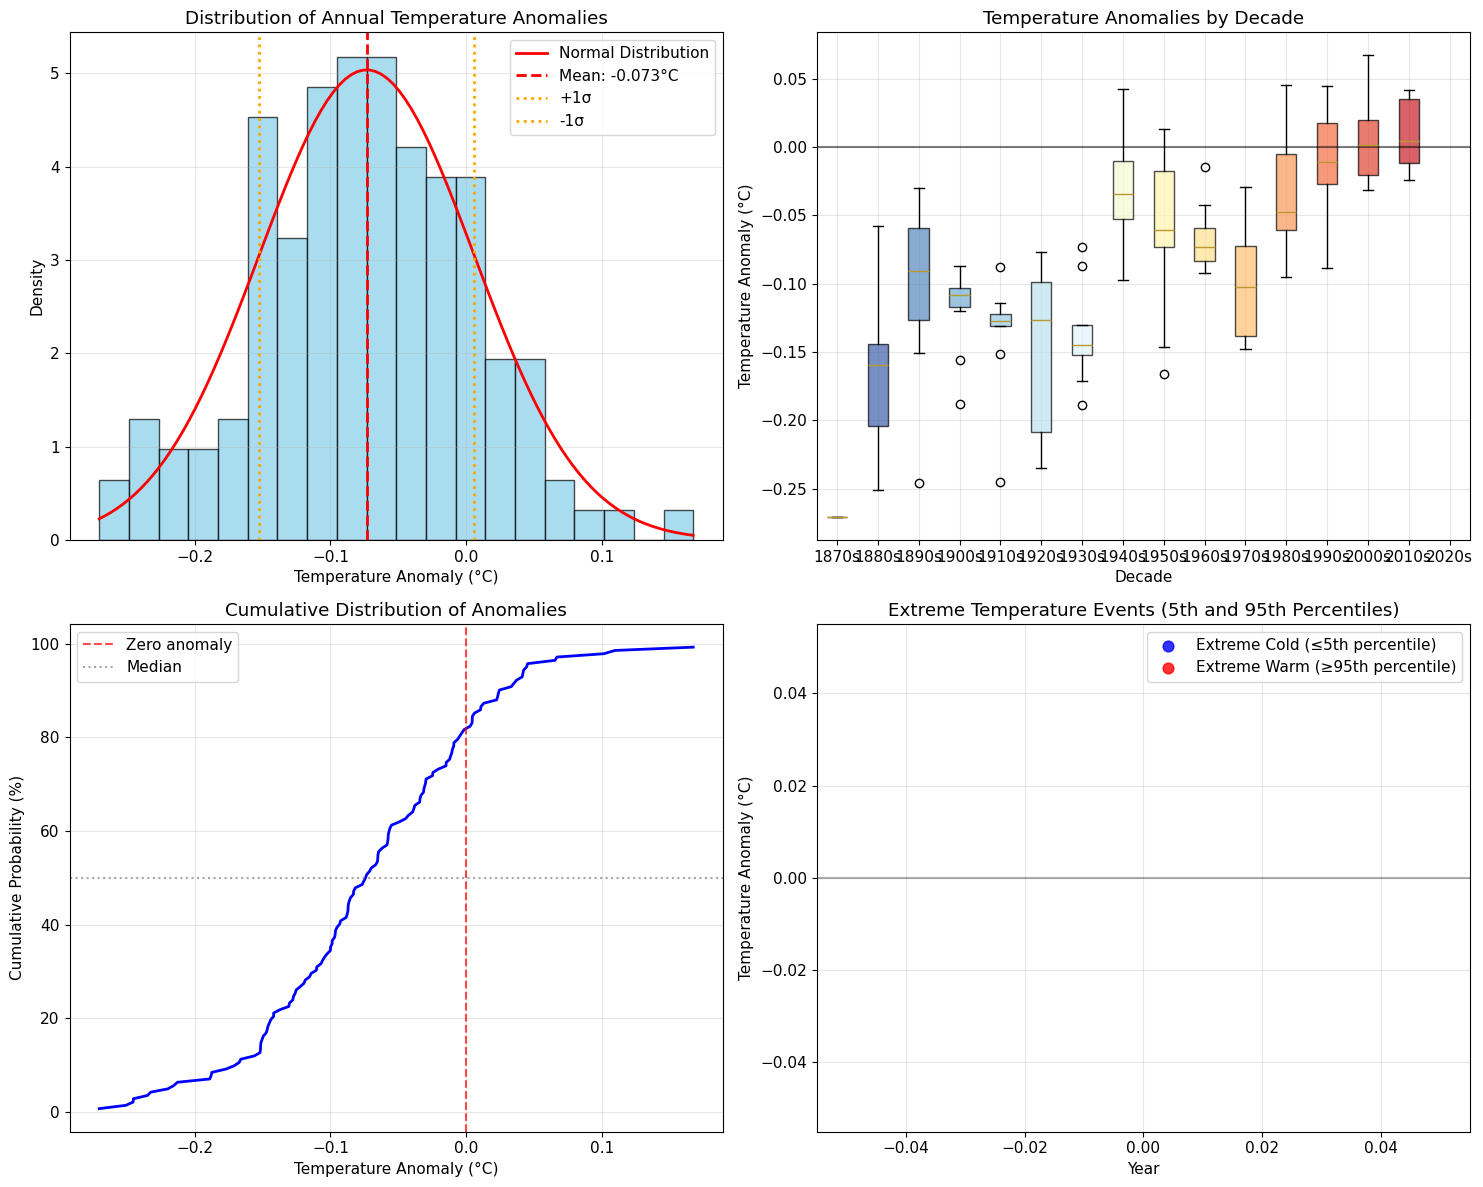

🌡️ EXTREME TEMPERATURE EVENTS
Coldest years (≤5th percentile, nan°C):

Warmest years (≥95th percentile, nan°C):


In [8]:
# Statistical analysis of temperature anomalies
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# 1. Histogram with statistical overlay
mean_anomaly = df['ANNUAL_ANOMALY'].mean()
std_anomaly = df['ANNUAL_ANOMALY'].std()

ax1.hist(df['ANNUAL_ANOMALY'], bins=20, density=True, alpha=0.7, 
         color='skyblue', edgecolor='black')

# Overlay normal distribution
x = np.linspace(df['ANNUAL_ANOMALY'].min(), df['ANNUAL_ANOMALY'].max(), 100)
normal_curve = (1/(std_anomaly * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean_anomaly)/std_anomaly)**2)
ax1.plot(x, normal_curve, 'r-', linewidth=2, label='Normal Distribution')

ax1.axvline(mean_anomaly, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_anomaly:.3f}°C')
ax1.axvline(mean_anomaly + std_anomaly, color='orange', linestyle=':', linewidth=2, label=f'+1σ')
ax1.axvline(mean_anomaly - std_anomaly, color='orange', linestyle=':', linewidth=2, label=f'-1σ')

ax1.set_xlabel('Temperature Anomaly (°C)')
ax1.set_ylabel('Density')
ax1.set_title('Distribution of Annual Temperature Anomalies')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Box plot by decade
df['DECADE'] = (df['YEAR'] // 10) * 10
decade_data = [df[df['DECADE'] == decade]['ANNUAL_ANOMALY'].values 
               for decade in sorted(df['DECADE'].unique())]
decade_labels = [f"{int(decade)}s" for decade in sorted(df['DECADE'].unique())]

box_plot = ax2.boxplot(decade_data, labels=decade_labels, patch_artist=True)
colors = plt.cm.RdYlBu_r(np.linspace(0, 1, len(box_plot['boxes'])))

for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5)
ax2.set_xlabel('Decade')
ax2.set_ylabel('Temperature Anomaly (°C)')
ax2.set_title('Temperature Anomalies by Decade')
ax2.grid(True, alpha=0.3)

# 3. Cumulative distribution
sorted_anomalies = np.sort(df['ANNUAL_ANOMALY'])
cumulative_prob = np.arange(1, len(sorted_anomalies) + 1) / len(sorted_anomalies)

ax3.plot(sorted_anomalies, cumulative_prob * 100, 'b-', linewidth=2)
ax3.axvline(0, color='red', linestyle='--', alpha=0.7, label='Zero anomaly')
ax3.axhline(50, color='gray', linestyle=':', alpha=0.7, label='Median')

ax3.set_xlabel('Temperature Anomaly (°C)')
ax3.set_ylabel('Cumulative Probability (%)')
ax3.set_title('Cumulative Distribution of Anomalies')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Extreme events analysis
# Calculate percentiles
p5 = np.percentile(df['ANNUAL_ANOMALY'], 5)
p95 = np.percentile(df['ANNUAL_ANOMALY'], 95)

extreme_cold = df[df['ANNUAL_ANOMALY'] <= p5]
extreme_warm = df[df['ANNUAL_ANOMALY'] >= p95]

ax4.scatter(extreme_cold['YEAR'], extreme_cold['ANNUAL_ANOMALY'], 
           color='blue', s=60, alpha=0.8, label=f'Extreme Cold (≤5th percentile)')
ax4.scatter(extreme_warm['YEAR'], extreme_warm['ANNUAL_ANOMALY'], 
           color='red', s=60, alpha=0.8, label=f'Extreme Warm (≥95th percentile)')

ax4.axhline(p5, color='blue', linestyle='--', alpha=0.5)
ax4.axhline(p95, color='red', linestyle='--', alpha=0.5)
ax4.axhline(0, color='black', linestyle='-', alpha=0.3)

ax4.set_xlabel('Year')
ax4.set_ylabel('Temperature Anomaly (°C)')
ax4.set_title('Extreme Temperature Events (5th and 95th Percentiles)')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print extreme events summary
print("🌡️ EXTREME TEMPERATURE EVENTS")
print("="*40)
print(f"Coldest years (≤5th percentile, {p5:.3f}°C):")
for _, row in extreme_cold.nsmallest(5, 'ANNUAL_ANOMALY').iterrows():
    print(f"  {int(row['YEAR'])}: {row['ANNUAL_ANOMALY']:.3f}°C")

print(f"\nWarmest years (≥95th percentile, {p95:.3f}°C):")
for _, row in extreme_warm.nlargest(5, 'ANNUAL_ANOMALY').iterrows():
    print(f"  {int(row['YEAR'])}: {row['ANNUAL_ANOMALY']:.3f}°C")

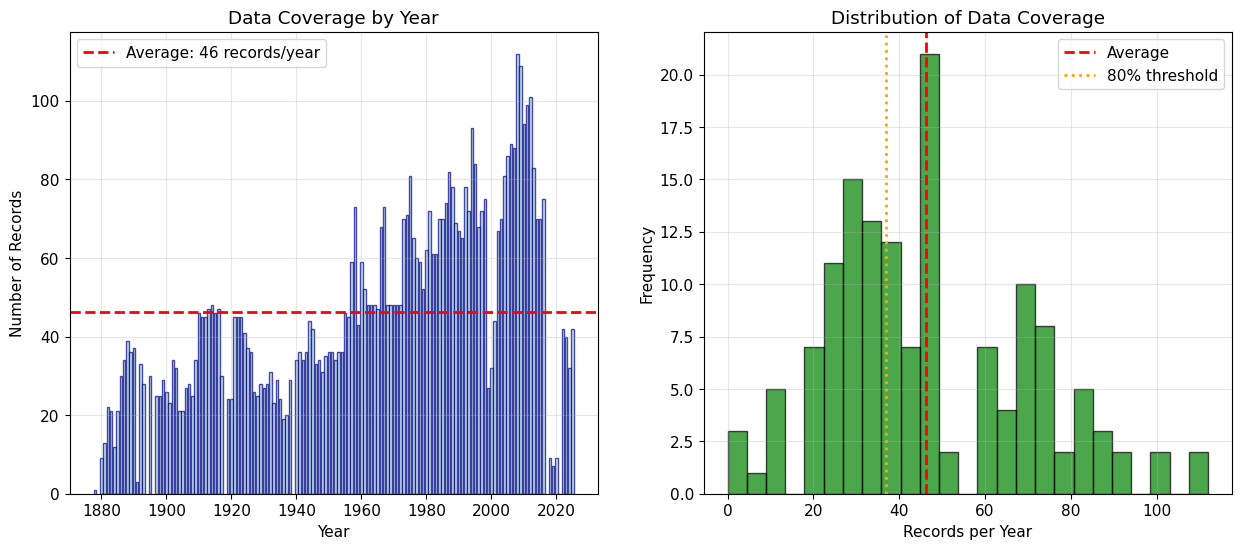

In [9]:
# Analyze data quality and coverage
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(15, 6))

# 1. Data coverage over time
ax1.bar(df['YEAR'], df['RECORD_COUNT'], alpha=0.7, color='lightblue', edgecolor='navy')
avg_records = df['RECORD_COUNT'].mean()
ax1.axhline(avg_records, color='red', linestyle='--', linewidth=2, 
           label=f'Average: {avg_records:.0f} records/year')

ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Records')
ax1.set_title('Data Coverage by Year')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Data quality metrics
quality_years = df['YEAR'][df['RECORD_COUNT'] >= avg_records * 0.8]  # Years with good coverage
ax2.hist(df['RECORD_COUNT'], bins=25, alpha=0.7, color='green', edgecolor='black')
ax2.axvline(avg_records, color='red', linestyle='--', linewidth=2, label='Average')
ax2.axvline(avg_records * 0.8, color='orange', linestyle=':', linewidth=2, 
           label='80% threshold')

ax2.set_xlabel('Records per Year')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Data Coverage')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Optional Cleanup

In [10]:
# !rm *.csv